In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

print("Ready.")


Ready.


In [2]:
H0 = 70.0
Omega_m = 0.3
Omega_L = 0.7

def H_ratio(z, w=-1.0):
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_L * (1 + z)**(3 * (1 + w)))

# Test it
print(f"w=-1.0, z=0: H_ratio = {H_ratio(0, w=-1.0):.4f}")
print(f"w=-1.0, z=1: H_ratio = {H_ratio(1, w=-1.0):.4f}")
print(f"w=-0.8, z=1: H_ratio = {H_ratio(1, w=-0.8):.4f}")
print(f"w=-1.2, z=1: H_ratio = {H_ratio(1, w=-1.2):.4f}")

w=-1.0, z=0: H_ratio = 1.0000
w=-1.0, z=1: H_ratio = 1.7607
w=-0.8, z=1: H_ratio = 1.8604
w=-1.2, z=1: H_ratio = 1.6917


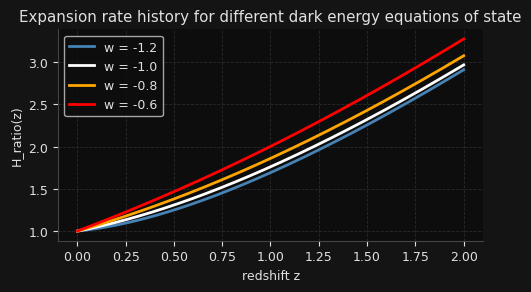

In [3]:
z = np.linspace(0.001, 2.0, 1000)

w_values = [-1.2, -1.0, -0.8, -0.6]
colors = ['steelblue', 'white', 'orange', 'red']

plt.figure()
for w, color in zip(w_values, colors):
    plt.plot(z, H_ratio(z, w=w), color=color, linewidth=2, label=f'w = {w}')

plt.xlabel('redshift z')
plt.ylabel('H_ratio(z)')
plt.title('Expansion rate history for different dark energy equations of state')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import matplotlib
print(matplotlib.matplotlib_fname())

/Users/saniasingh/.matplotlib/matplotlibrc


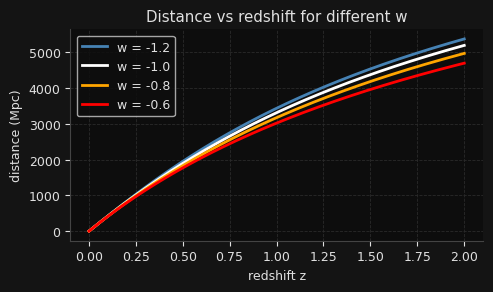

In [5]:
c = 3e5

def distance(z_val, w=-1.0):
    integral, _ = quad(lambda zp: 1.0 / H_ratio(zp, w=w), 0, z_val)
    return (c / H0) * integral

z = np.linspace(0.001, 2.0, 1000)

w_values = [-1.2, -1.0, -0.8, -0.6]
colors = ['steelblue', 'white', 'orange', 'red']

plt.figure()
for w, color in zip(w_values, colors):
    d = np.array([distance(zi, w=w) for zi in z])
    plt.plot(z, d, color=color, linewidth=2, label=f'w = {w}')

plt.xlabel('redshift z')
plt.ylabel('distance (Mpc)')
plt.title('Distance vs redshift for different w')
plt.legend()
plt.tight_layout()
plt.show()